## Open notebook in:
| Colab                                 
:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nicolepcx/transformers-the-definitive-guide/blob/master/CH12/ch12_sam3_agent.ipynb)                                             

# About This Notebook

This notebook demonstrates how to build a SAM 3 agent style workflow where a multimodal LLM (served through vLLM) collaborates with the SAM 3 model for segmentation based on natural language queries. The goal is to show how an LLM can reason about a prompt such as “the leftmost red yarn ball” and then call SAM 3 as a tool to perform the actual segmentation.

This notebook integrates
• SAM 3 model setup and processor initialization
• vLLM based serving of Qwen3 VL 8B Thinking as the reasoning component
• an agent loop that routes text prompts to the LLM and segmentation prompts to SAM 3

This notebook was adapted from the official examples in the facebookresearch/sam3 repository. The original project and codebase can be found here: https://github.com/facebookresearch/sam3


# Install Dependencies

In [ ]:
%%bash
git clone https://github.com/facebookresearch/sam3.git
cd sam3
git checkout 96914d2425f90a64f45ca977c2b5165418099543
pip install -e ".[notebooks]"
pip install -q vllm==0.27.1 bitsandbytes==0.50.1

In [ ]:
!pip uninstall -y torchaudio
!pip install torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu130
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.5 MB/s eta 0:00:00


# 以下はランタイムを再起動してから実行すること

In [ ]:
%cd /content/sam3

/content/sam3


## Imports

In [ ]:
import os
import time
from functools import partial

import requests
import sam3
import torch
from huggingface_hub import login
from IPython import display
from PIL import Image
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

In [ ]:
import platform

import torch
import torchvision
import torchaudio

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchAudio:", torchaudio.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Python: 3.12.13
PyTorch: 2.13.0+cu130
TorchVision: 0.28.0+cu130
TorchAudio: 2.11.0+cu130
CUDA: 13.0
GPU: Tesla T4


# Init SAM

SAM 3の重みはHugging Face上でゲート処理されている。以下のセルを実行する前に、モデルへのアクセスをリクエストし、承認される必要がある。

In [ ]:
login()

In [ ]:
bpe_path = "/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.5)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

# Start vLLM Server in Background and Allow Local Media Path

原著のノートブックでは[Qwen/Qwen3-VL-8B-Thinking](https://huggingface.co/Qwen/Qwen3-VL-8B-Thinking)を使用していたが、ColabのT4で動作させるために[unsloth/Qwen3-VL-2B-Instruct-GGUF](https://huggingface.co/unsloth/Qwen3-VL-2B-Instruct-GGUF)に変更している。

In [ ]:
%%bash
vllm serve unsloth/Qwen3-VL-2B-Instruct-bnb-4bit \
  --served-model-name qwen3_vl_2b_instruct \
  --host 0.0.0.0 \
  --port 8001 \
  --enforce-eager \
  --max-model-len 16384 \
  --gpu-memory-utilization 0.5 \
  --allowed-local-media-path / \
  > vllm_server.log 2>&1 &

In [ ]:
# サーバーが起動するまで待機
for _ in range(60):
    try:
        response = requests.get(
            "http://localhost:8001/v1/models",
            timeout=2,
        )
        if response.ok:
            print("vLLM server is ready.")
            break
    except requests.RequestException:
        pass

    time.sleep(10)
else:
    raise RuntimeError("vLLM server did not start.")

vLLM server is ready.


## vLLM Configs


In [ ]:
LLM_CONFIGS = {
    "qwen3_vl_2b_instruct": {
        "provider": "vllm",
        # ATT: this must match served_model_name in vLLM
        "model": "qwen3_vl_2b_instruct",
    },
}

model = "qwen3_vl_2b_instruct"
LLM_API_KEY = "DUMMY_API_KEY"

llm_config = LLM_CONFIGS[model]
llm_config["api_key"] = LLM_API_KEY
llm_config["name"] = model

if llm_config["provider"] == "vllm":
    LLM_SERVER_URL = "http://127.0.0.1:8001/v1"
else:
    LLM_SERVER_URL = llm_config["base_url"]

print("LLM_SERVER_URL:", LLM_SERVER_URL)
print("llm_config:", llm_config)

LLM_SERVER_URL: http://127.0.0.1:8001/v1
llm_config: {'provider': 'vllm', 'model': 'qwen3_vl_2b_instruct', 'api_key': 'DUMMY_API_KEY', 'name': 'qwen3_vl_2b_instruct'}


# Load Image from Google Drive

In [ ]:
file_id = "1IKjM-BueAJw9xxXpCmQReWeWoKOzhv-j"
destination = "cats_balls.jpeg"
!gdown {file_id} -O {destination}
display.Image(filename=destination, width=400)

In [ ]:
def resize_for_vlm(input_path, output_path=None, max_side=512):
    with Image.open(input_path) as img:
        img = img.convert("RGB")

        width, height = img.size
        scale = min(1.0, max_side / max(width, height))

        new_size = (
            round(width * scale),
            round(height * scale),
        )

        if new_size != img.size:
            img = img.resize(new_size, Image.Resampling.LANCZOS)

        if output_path is None:
            root, _ = os.path.splitext(input_path)
            output_path = f"{root}_resized.jpg"

        img.save(output_path, "JPEG", quality=90)

    return output_path

output_path = resize_for_vlm(destination)

# Run SAM3 Agent Inference with Qwen 3 VL

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: the leftmost red ball
> Image path: /content/sam3/cats_balls_resized.jpg



------------------------------ Round 1------------------------------



image_path /content/sam3/cats_balls_resized.jpg
🔍 Calling model qwen3_vl_2b_instruct...

>>> MLLM Response [start]
1. Analyze: The raw input image shows a small, sleeping kitten nestled in a knitted blanket with several colorful balls of yarn surrounding it. The balls are red, blue, yellow, and teal. The red balls are on the left side of the image, and they are positioned near the leftmost part of the image. The user's query is to ground "the leftmost red ball."

2. Think: The user is asking to ground "the leftmost red ball." The red balls are located on the left side of the image, and they are the first red balls from the left when viewing the image. The ball on the far left is the leftmost red ball.

3. Remind: Each call to the se

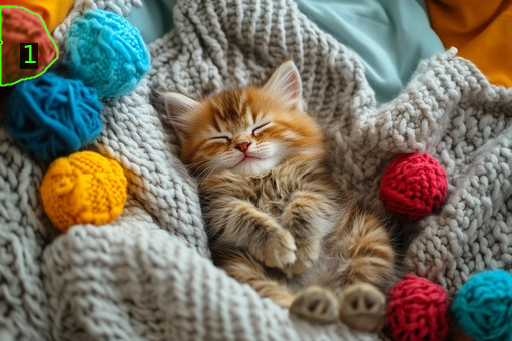

In [ ]:
# prepare input args
prompt = "the leftmost red ball"
image = os.path.abspath(output_path)
send_generate_request = partial(
    send_generate_request_orig,
    server_url=LLM_SERVER_URL,
    model=llm_config["model"],
    api_key=llm_config["api_key"],
    max_tokens=1024,
)
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)

# run single image inference
with torch.inference_mode():
    with torch.autocast("cuda", dtype=torch.float16):
        output_image_path = run_single_image_inference(
            image,
            prompt,
            llm_config,
            send_generate_request,
            call_sam_service,
            debug=True,
            output_dir="agent_output",
        )

# display output
if output_image_path is not None:
    display.display(display.Image(filename=output_image_path))